In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
import pandas as pd

resume_data = pd.read_csv("Resume.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", resume_data.shape)

display(resume_data.head())

Dataset loaded successfully!
Dataset shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [33]:
print("===== DATASET INFORMATION =====")

print("Shape:", resume_data.shape)

print("\nColumns:")
print(resume_data.columns.tolist())

print("\nMissing values:")
print(resume_data.isnull().sum())

print("\nDuplicate rows:")
print(resume_data.duplicated().sum())

print("\nResume categories:")
print(resume_data["Category"].value_counts())

===== DATASET INFORMATION =====
Shape: (2484, 4)

Columns:
['ID', 'Resume_str', 'Resume_html', 'Category']

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Duplicate rows:
0

Resume categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [34]:
display(resume_data.head())

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [35]:
resume_data = resume_data[["ID", "Category", "Resume_str"]].copy()

print("Columns after selection:")
print(resume_data.columns.tolist())

print("\nDataset shape:", resume_data.shape)

Columns after selection:
['ID', 'Category', 'Resume_str']

Dataset shape: (2484, 3)


In [36]:
print("Missing resume texts:", resume_data["Resume_str"].isnull().sum())

Missing resume texts: 0


In [37]:
resume_data = resume_data.drop_duplicates(subset=["Resume_str"])

print("Duplicates removed.")
print("Final dataset shape:", resume_data.shape)

Duplicates removed.
Final dataset shape: (2482, 3)


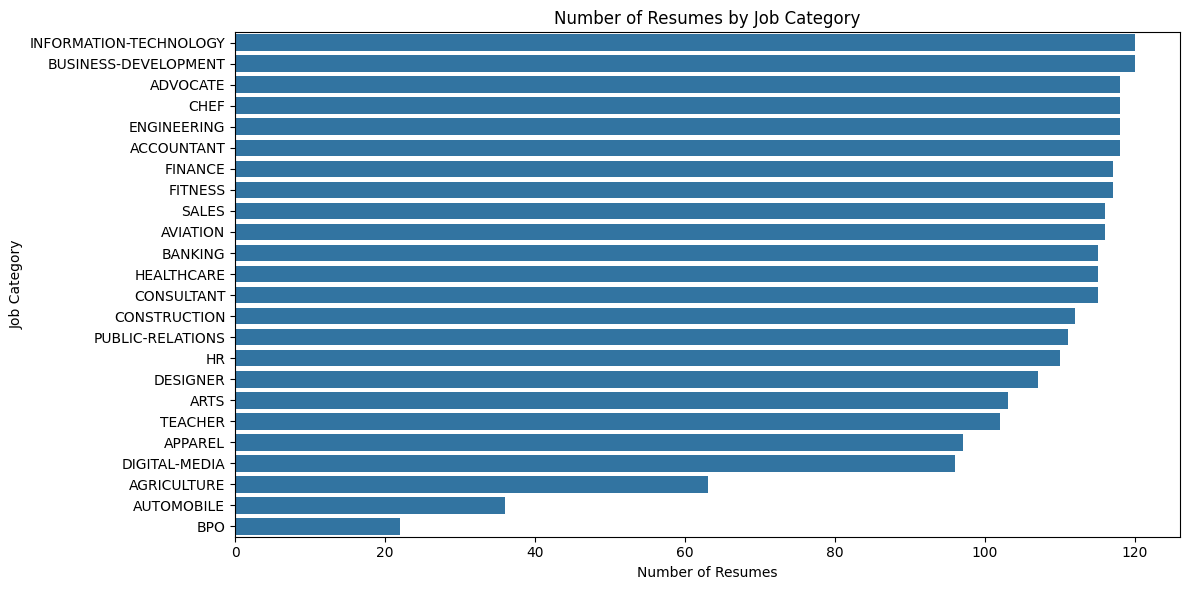

In [38]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=resume_data,
    y="Category",
    order=resume_data["Category"].value_counts().index
)

plt.title("Number of Resumes by Job Category")
plt.xlabel("Number of Resumes")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

In [39]:
import re
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = " ".join(
        word for word in text.split()
        if word not in stop_words
    )
    return text.strip()

resume_data["Cleaned_Resume"] = resume_data["Resume_str"].apply(clean_text)

print("NLP preprocessing completed successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NLP preprocessing completed successfully!


In [40]:
display(
    resume_data[["Resume_str", "Cleaned_Resume"]].head(3)
)

,Resume_str,Cleaned_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary years experience recruitin...


In [41]:
resume_data["Resume_Length"] = resume_data["Cleaned_Resume"].apply(
    lambda x: len(x.split())
)

print("Average resume length:",
      round(resume_data["Resume_Length"].mean(), 2), "words")

print("Shortest resume:",
      resume_data["Resume_Length"].min(), "words")

print("Longest resume:",
      resume_data["Resume_Length"].max(), "words")

Average resume length: 593.48 words
Shortest resume: 0 words
Longest resume: 3581 words


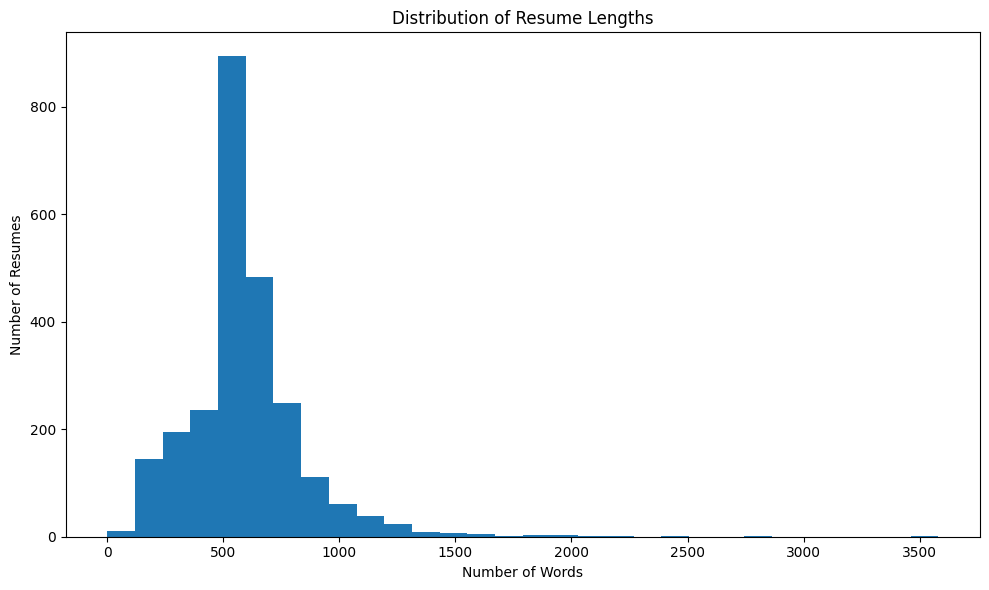

In [42]:
plt.figure(figsize=(10, 6))

plt.hist(
    resume_data["Resume_Length"],
    bins=30
)

plt.title("Distribution of Resume Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Resumes")

plt.tight_layout()
plt.show()

In [43]:
print("===== RESUME SCREENING SYSTEM =====")

job_description = input(
    "Enter the Job Description:\n\n"
)

print("\nJob description received successfully!")

===== RESUME SCREENING SYSTEM =====
Enter the Job Description:

skills

Job description received successfully!


In [44]:
cleaned_job_description = clean_text(job_description)

print("Cleaned job description:")
print(cleaned_job_description)

Cleaned job description:
skills


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(
    max_features=5000
)

resume_vectors = vectorizer.fit_transform(
    resume_data["Cleaned_Resume"]
)

job_vector = vectorizer.transform(
    [cleaned_job_description]
)

similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
).flatten()

resume_data["Match_Score"] = (
    similarity_scores * 100
).round(2)

print("Resume matching completed successfully!")

Resume matching completed successfully!


In [46]:
ranked_resumes = resume_data.sort_values(
    by="Match_Score",
    ascending=False
).reset_index(drop=True)

ranked_resumes["Rank"] = ranked_resumes.index + 1

print("===== TOP 10 CANDIDATES =====")

display(
    ranked_resumes[
        ["Rank", "ID", "Category", "Match_Score"]
    ].head(10)
)

===== TOP 10 CANDIDATES =====


,Rank,ID,Category,Match_Score
0,1,24588864,ADVOCATE,20.77
1,2,24221960,CHEF,18.62
2,3,24544244,AVIATION,16.71
3,4,29926588,ADVOCATE,15.41
4,5,76010167,DESIGNER,14.90
5,6,10898339,SALES,14.22
6,7,16223371,SALES,14.14
7,8,19336728,HR,13.79
8,9,39581020,SALES,13.20
9,10,15581242,SALES,12.73


In [47]:
threshold = float(
    input("Enter minimum match score for shortlisting (%): ")
)

shortlisted = ranked_resumes[
    ranked_resumes["Match_Score"] >= threshold
].copy()

print("\n===== SHORTLISTED CANDIDATES =====")
print("Minimum Match Score:", threshold, "%")
print("Candidates Shortlisted:", len(shortlisted))

display(
    shortlisted[
        ["Rank", "ID", "Category", "Match_Score"]
    ].head(20)
)

Enter minimum match score for shortlisting (%): 30

===== SHORTLISTED CANDIDATES =====
Minimum Match Score: 30.0 %
Candidates Shortlisted: 0


,Rank,ID,Category,Match_Score


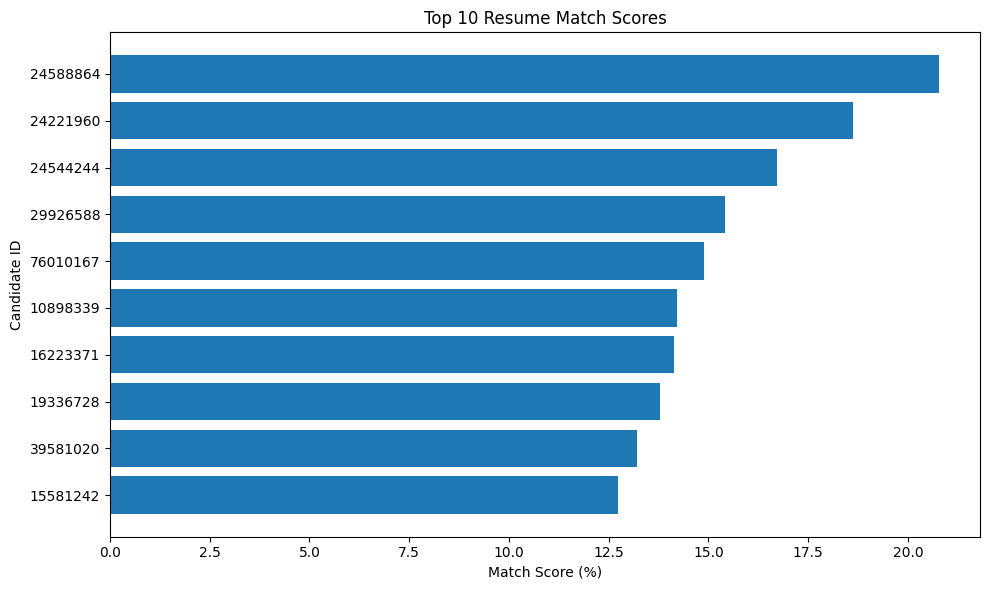

In [48]:
top_candidates = ranked_resumes.head(10).sort_values(
    "Match_Score"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_candidates["ID"].astype(str),
    top_candidates["Match_Score"]
)

plt.title("Top 10 Resume Match Scores")
plt.xlabel("Match Score (%)")
plt.ylabel("Candidate ID")

plt.tight_layout()
plt.show()

In [49]:
print("===== RESUME SCREENING SUMMARY =====")

print(f"Total resumes analyzed: {len(resume_data)}")
print(f"Minimum match score: {threshold:.2f}%")
print(f"Shortlisted candidates: {len(shortlisted)}")

if len(ranked_resumes) > 0:
    print(
        f"Highest match score: "
        f"{ranked_resumes['Match_Score'].max():.2f}%"
    )

    print(
        f"Average match score: "
        f"{ranked_resumes['Match_Score'].mean():.2f}%"
    )

===== RESUME SCREENING SUMMARY =====
Total resumes analyzed: 2482
Minimum match score: 30.00%
Shortlisted candidates: 0
Highest match score: 20.77%
Average match score: 2.84%


In [50]:
final_results = ranked_resumes[
    ["Rank", "ID", "Category", "Match_Score"]
].head(10).copy()

final_results.columns = [
    "Rank",
    "Candidate ID",
    "Resume Category",
    "Match Score (%)"
]

display(final_results)

,Rank,Candidate ID,Resume Category,Match Score (%)
0,1,24588864,ADVOCATE,20.77
1,2,24221960,CHEF,18.62
2,3,24544244,AVIATION,16.71
3,4,29926588,ADVOCATE,15.41
4,5,76010167,DESIGNER,14.90
5,6,10898339,SALES,14.22
6,7,16223371,SALES,14.14
7,8,19336728,HR,13.79
8,9,39581020,SALES,13.20
9,10,15581242,SALES,12.73


In [51]:
final_results.to_csv(
    "resume_screening_results.csv",
    index=False
)

print("Screening results saved successfully!")

Screening results saved successfully!


In [52]:
shortlisted_results = shortlisted[
    ["Rank", "ID", "Category", "Match_Score"]
].copy()

shortlisted_results.columns = [
    "Rank",
    "Candidate ID",
    "Resume Category",
    "Match Score (%)"
]

shortlisted_results.to_csv(
    "shortlisted_candidates.csv",
    index=False
)

print("Shortlisted candidates saved successfully!")

Shortlisted candidates saved successfully!


In [53]:
final_dataset = resume_data[
    ["ID", "Category", "Cleaned_Resume", "Match_Score"]
].copy()

print("Final dataset columns:")
print(final_dataset.columns.tolist())

display(final_dataset.head())

Final dataset columns:
['ID', 'Category', 'Cleaned_Resume', 'Match_Score']


,ID,Category,Cleaned_Resume,Match_Score
0,16852973,HR,hr administrator marketing associate hr admini...,4.35
1,22323967,HR,hr specialist us hr operations summary versati...,1.03
2,33176873,HR,hr director summary years experience recruitin...,1.67
3,27018550,HR,hr specialist summary dedicated driven dynamic...,5.01
4,17812897,HR,hr manager skill highlights hr skills hr depar...,1.74


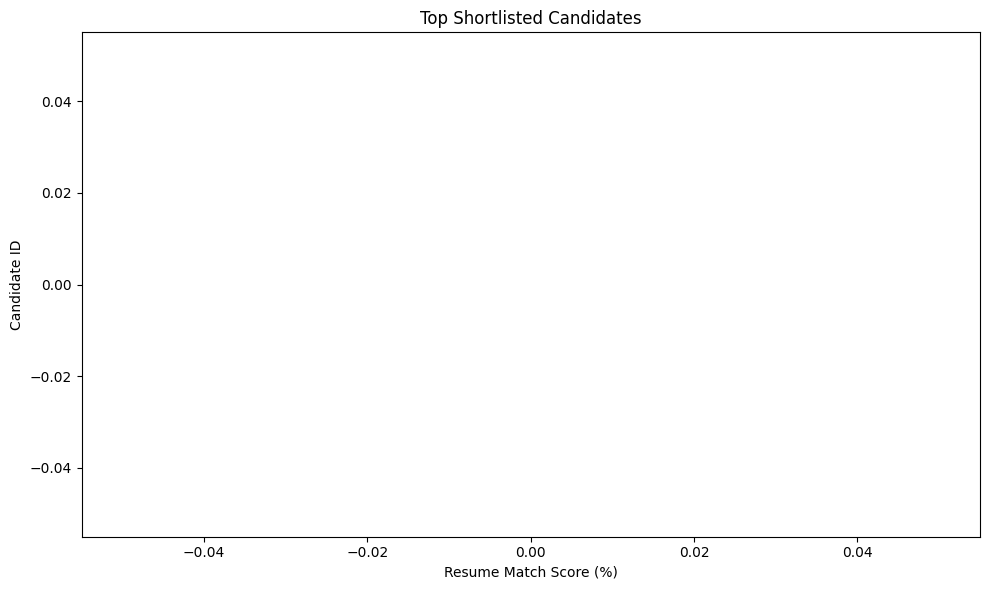

In [54]:
plt.figure(figsize=(10, 6))

top_shortlisted = shortlisted.head(10).sort_values(
    "Match_Score"
)

plt.barh(
    top_shortlisted["ID"].astype(str),
    top_shortlisted["Match_Score"]
)

plt.title("Top Shortlisted Candidates")
plt.xlabel("Resume Match Score (%)")
plt.ylabel("Candidate ID")

plt.tight_layout()
plt.show()

Project Conclusion

This project successfully developed an AI Resume Screening System that analyzes resumes based on a user-provided job description. NLP techniques were used to clean and preprocess the resume text, while TF-IDF was used for feature extraction. Cosine similarity was then applied to calculate the similarity between each resume and the job description. The resumes were ranked according to their match scores, and candidates above the selected threshold were shortlisted. The project demonstrates how NLP can be used to automate and simplify the initial resume screening process.

In [82]:
%%writefile app.py

import streamlit as st
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# -----------------------------
# Page Configuration
# -----------------------------

st.set_page_config(
    page_title="AI Resume Screening System",
    page_icon="📄",
    layout="wide"
)


# -----------------------------
# Load Resume Dataset
# -----------------------------

@st.cache_data
def load_data():
    return pd.read_csv("Resume.csv")


resume_data = load_data()


# -----------------------------
# Text Cleaning
# -----------------------------

def clean_text(text):
    return str(text).lower()


# -----------------------------
# Application Title
# -----------------------------

st.title("📄 AI Resume Screening System")

st.write(
    "Enter a job description to find and rank the most relevant "
    "resumes using TF-IDF and Cosine Similarity."
)


# -----------------------------
# Dataset Information
# -----------------------------

st.info(f"📊 {len(resume_data)} resumes available for screening.")


# -----------------------------
# Job Description
# -----------------------------

st.subheader("💼 Job Description")

job_description = st.text_area(
    "Paste the job description below:",
    height=200,
    placeholder=(
        "Example: We are looking for a Data Scientist with "
        "skills in Python, Machine Learning, SQL, and data analysis."
    )
)


# -----------------------------
# Shortlisting Threshold
# -----------------------------

threshold = st.slider(
    "Minimum Match Score for Shortlisting (%)",
    min_value=0,
    max_value=100,
    value=50
)


# -----------------------------
# Screen Resumes
# -----------------------------

if st.button("🔍 Screen Resumes"):

    if not job_description.strip():

        st.warning("Please enter a job description first.")

    else:

        with st.spinner("Analyzing resumes..."):

            # Use the actual Resume_str column
            resume_text = (
                resume_data["Resume_str"]
                .fillna("")
                .apply(clean_text)
            )

            cleaned_job_description = clean_text(
                job_description
            )

            # -----------------------------
            # TF-IDF
            # -----------------------------

            vectorizer = TfidfVectorizer(
                max_features=5000,
                stop_words="english"
            )

            resume_vectors = vectorizer.fit_transform(
                resume_text
            )

            job_vector = vectorizer.transform(
                [cleaned_job_description]
            )

            # -----------------------------
            # Cosine Similarity
            # -----------------------------

            similarity_scores = cosine_similarity(
                resume_vectors,
                job_vector
            ).flatten()

            # -----------------------------
            # Create Results
            # -----------------------------

            results = resume_data[
                ["ID", "Category"]
            ].copy()

            results["Match_Score"] = (
                similarity_scores * 100
            ).round(2)

            # Rank candidates
            results = results.sort_values(
                by="Match_Score",
                ascending=False
            ).reset_index(drop=True)

            results["Rank"] = results.index + 1

            # -----------------------------
            # Shortlisting
            # -----------------------------

            shortlisted = results[
                results["Match_Score"] >= threshold
            ]


        st.success("✅ Resume screening completed successfully!")


        # -----------------------------
        # Summary
        # -----------------------------

        col1, col2, col3 = st.columns(3)

        with col1:
            st.metric(
                "Resumes Analyzed",
                len(results)
            )

        with col2:
            st.metric(
                "Shortlisted",
                len(shortlisted)
            )

        with col3:
            st.metric(
                "Highest Match",
                f"{results['Match_Score'].max():.2f}%"
            )


        # -----------------------------
        # Top Candidates
        # -----------------------------

        st.subheader("🏆 Top 10 Candidates")

        top_candidates = results.head(10).copy()

        top_candidates.columns = [
            "Candidate ID",
            "Resume Category",
            "Match Score (%)",
            "Rank"
        ]

        st.dataframe(
            top_candidates[
                [
                    "Rank",
                    "Candidate ID",
                    "Resume Category",
                    "Match Score (%)"
                ]
            ],
            use_container_width=True,
            hide_index=True
        )


        # -----------------------------
        # Shortlisted Candidates
        # -----------------------------

        st.subheader("✅ Shortlisted Candidates")

        if len(shortlisted) > 0:

            shortlisted_display = shortlisted.copy()

            shortlisted_display.columns = [
                "Candidate ID",
                "Resume Category",
                "Match Score (%)",
                "Rank"
            ]

            st.dataframe(
                shortlisted_display[
                    [
                        "Rank",
                        "Candidate ID",
                        "Resume Category",
                        "Match Score (%)"
                    ]
                ],
                use_container_width=True,
                hide_index=True
            )

        else:

            st.warning(
                "No candidates reached the selected "
                "shortlisting threshold."
            )


        # -----------------------------
        # Visualization
        # -----------------------------

        st.subheader("📊 Top 10 Resume Match Scores")

        chart_data = (
            results.head(10)
            .set_index("ID")["Match_Score"]
        )

        st.bar_chart(chart_data)


        # -----------------------------
        # Download Results
        # -----------------------------

        csv_data = results.to_csv(
            index=False
        )

        st.download_button(
            label="⬇️ Download Screening Results",
            data=csv_data,
            file_name="resume_screening_results.csv",
            mime="text/csv"
        )

Overwriting app.py


In [76]:
!pip install -q streamlit

In [83]:
!streamlit run app.py &>/content/logs.txt &

In [84]:
!cat /content/logs.txt



2026-08-24 19:43:07.910 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.145.213.234:8501



In [85]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
!./cloudflared tunnel --url http://localhost:8501

2026-08-24T19:43:16Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-24T19:43:16Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-24T19:43:21Z INF +--------------------------------------------------------------------------------------------+
2026-08-24T19:43:21Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-24T19:43:21Z INF |  https://mae-universities-skirts-dans.trycloudflare.co